# Harsh-Environment Quantum Sensing: Stressing the Ring Resonator

`dgs/optical_loops.py`'s ring resonator model (finesse, resonance width,
critical coupling) is one of this session's three kept, verified modules.
This notebook stresses it three physically different ways -- temperature,
ionizing radiation, and mechanical vibration -- and checks each effect
against the ring's OWN resonance linewidth, the actual criterion for
whether a sensor still functions, not just "is there some effect."

The radiation section produces a genuine, non-obvious finding: a compact
microring (round-trip path ~60 microns) barely notices a radiation dose
that would force `dgs.optical_loops`'s recirculating fiber loop (5 km
path) to need hundreds of extra dB of amplifier gain just to stay
lossless -- the SAME loss-per-length physics, wildly different outcomes,
purely from path length. Engine:
`dgs/harsh_environment_quantum_sensing.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt

from dgs import optical_loops as ol
from dgs import harsh_environment_quantum_sensing as hes

print('Setup complete.')


Setup complete.


## 1. Thermal Drift vs. Resonance Linewidth

The thermo-optic effect shifts a ring's resonance wavelength; checked
here against the ring's own FWHM (derived from
`dgs.optical_loops.ring_FWHM_phase`).


In [2]:
for dT in (0.5, 1.0, 3.0, 5.0, 10.0):
    check = hes.verify_thermal_detuning_vs_linewidth(dT)
    print(f"dT={dT:>5.1f}K: shift={check['delta_lambda_nm']:.4f}nm, "
          f"FWHM={check['fwhm_lambda_nm']:.4f}nm, fraction={check['fraction_of_linewidth']:.2f}, "
          f"exceeds: {check['exceeds_linewidth']}")


dT=  0.5K: shift=0.0581nm, FWHM=0.3641nm, fraction=0.16, exceeds: False
dT=  1.0K: shift=0.1163nm, FWHM=0.3641nm, fraction=0.32, exceeds: False
dT=  3.0K: shift=0.3488nm, FWHM=0.3641nm, fraction=0.96, exceeds: False
dT=  5.0K: shift=0.5813nm, FWHM=0.3641nm, fraction=1.60, exceeds: True
dT= 10.0K: shift=1.1625nm, FWHM=0.3641nm, fraction=3.19, exceeds: True


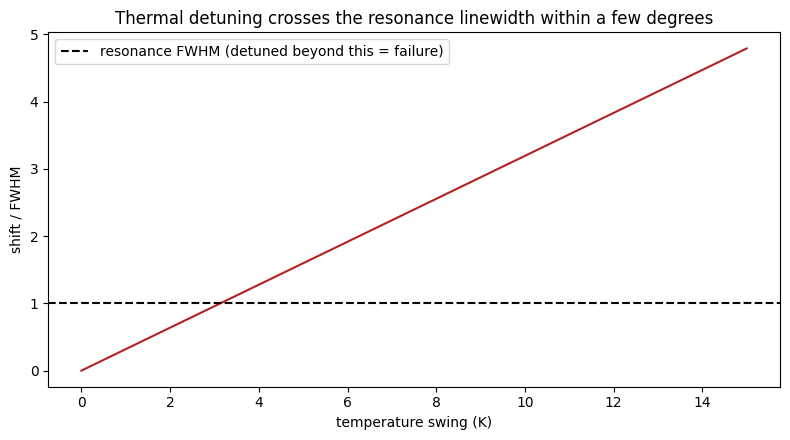

In [3]:
dT_range = np.linspace(0, 15, 100)
fractions = [hes.verify_thermal_detuning_vs_linewidth(dT)['fraction_of_linewidth'] for dT in dT_range]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(dT_range, fractions, color='firebrick')
ax.axhline(1.0, color='black', ls='--', label='resonance FWHM (detuned beyond this = failure)')
ax.set_xlabel('temperature swing (K)'); ax.set_ylabel('shift / FWHM')
ax.set_title('Thermal detuning crosses the resonance linewidth within a few degrees')
ax.legend()
plt.tight_layout()
plt.savefig('harsh_env_thermal_drift.png', dpi=100, bbox_inches='tight')
plt.show()


## 2. Radiation: Microring vs. Recirculating Fiber Loop

Both reuse `dgs.optical_loops` functions directly (`ring_finesse`,
`loop_threshold_gain_dB`) -- only the physical path length differs.


In [4]:
print('Microring (path length ~63 um):')
doses_ring = [0, 10, 50, 100, 500]
finesses = []
for dose in doses_ring:
    r = hes.microring_finesse_under_radiation(dose)
    finesses.append(r['finesse'])
    print(f"  dose={dose:>4}krad: finesse={r['finesse']:.4f} (change: {r['finesse_relative_change']:.2e})")

print('\nRecirculating fiber loop (path length 5 km):')
doses_loop = [0, 1, 5, 10, 20]
gains = []
for dose in doses_loop:
    r = hes.recirculating_loop_threshold_gain_under_radiation(dose)
    gains.append(r['threshold_gain_dB'])
    print(f"  dose={dose:>4}krad: threshold_gain={r['threshold_gain_dB']:>7.2f}dB "
          f"(+{r['additional_gain_needed_dB']:.2f}dB needed)")


Microring (path length ~63 um):
  dose=   0krad: finesse=25.0036 (change: 0.00e+00)
  dose=  10krad: finesse=25.0035 (change: -2.88e-06)
  dose=  50krad: finesse=25.0032 (change: -1.44e-05)
  dose= 100krad: finesse=25.0029 (change: -2.88e-05)
  dose= 500krad: finesse=25.0000 (change: -1.44e-04)

Recirculating fiber loop (path length 5 km):
  dose=   0krad: threshold_gain=   2.00dB (+0.00dB needed)
  dose=   1krad: threshold_gain=  27.00dB (+25.00dB needed)
  dose=   5krad: threshold_gain= 127.00dB (+125.00dB needed)
  dose=  10krad: threshold_gain= 252.00dB (+250.00dB needed)
  dose=  20krad: threshold_gain= 502.00dB (+500.00dB needed)


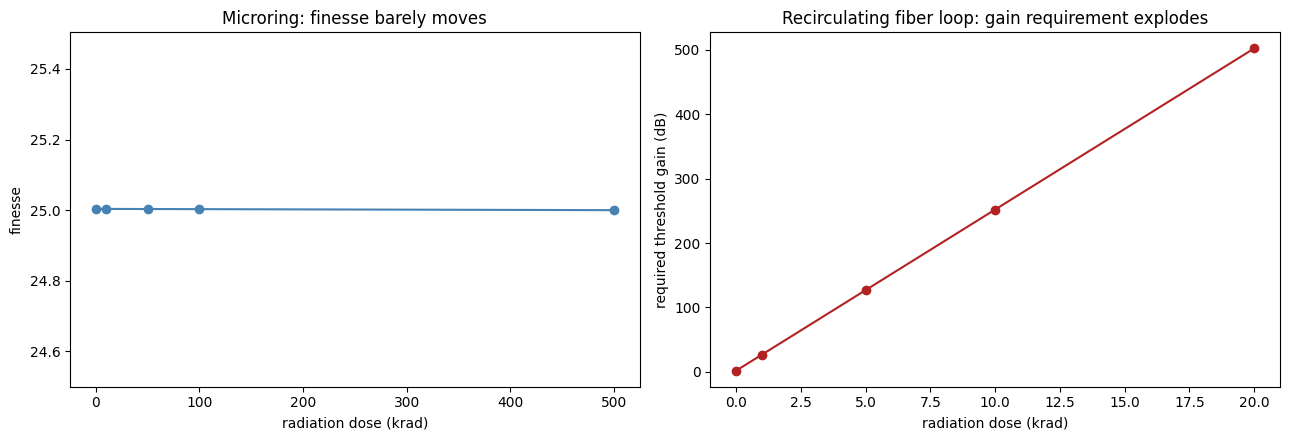

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(doses_ring, finesses, 'o-', color='steelblue')
axes[0].set_xlabel('radiation dose (krad)'); axes[0].set_ylabel('finesse')
axes[0].set_title('Microring: finesse barely moves')
axes[0].set_ylim(min(finesses)-0.5, max(finesses)+0.5)

axes[1].plot(doses_loop, gains, 'o-', color='firebrick')
axes[1].set_xlabel('radiation dose (krad)'); axes[1].set_ylabel('required threshold gain (dB)')
axes[1].set_title('Recirculating fiber loop: gain requirement explodes')

plt.tight_layout()
plt.savefig('harsh_env_radiation_contrast.png', dpi=100, bbox_inches='tight')
plt.show()


## 3. Vibration-Induced Phase Noise vs. Resonance Linewidth

Mechanical vibration modulates the effective optical path length,
checked the same way as the thermal case.


In [6]:
for dL_nm in (0.1, 1.0, 5.0, 10.0, 20.0):
    check = hes.verify_vibration_jitter_vs_linewidth(dL_nm * 1e-9)
    print(f"dL={dL_nm:>5.1f}nm: jitter={check['phase_jitter_rad']:.4f}rad, "
          f"FWHM={check['fwhm_phase_rad']:.4f}rad, fraction={check['fraction_of_linewidth']:.3f}, "
          f"exceeds: {check['exceeds_linewidth']}")


dL=  0.1nm: jitter=0.0010rad, FWHM=0.2513rad, fraction=0.004, exceeds: False
dL=  1.0nm: jitter=0.0097rad, FWHM=0.2513rad, fraction=0.039, exceeds: False
dL=  5.0nm: jitter=0.0486rad, FWHM=0.2513rad, fraction=0.194, exceeds: False
dL= 10.0nm: jitter=0.0973rad, FWHM=0.2513rad, fraction=0.387, exceeds: False
dL= 20.0nm: jitter=0.1946rad, FWHM=0.2513rad, fraction=0.774, exceeds: False


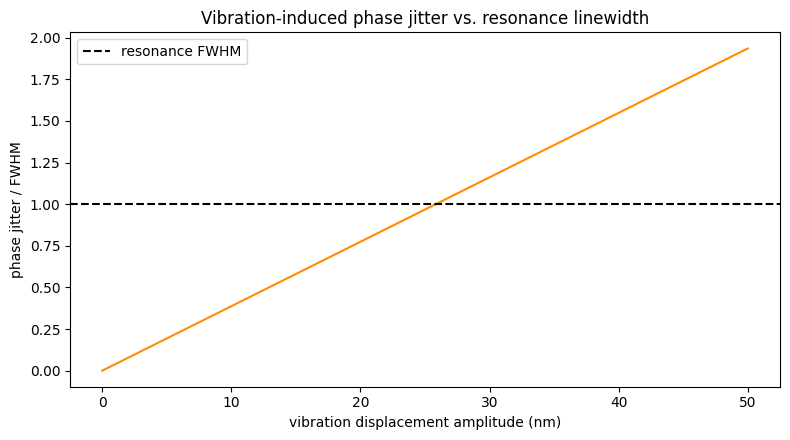

In [7]:
dL_range = np.linspace(0, 50, 100)
vib_fractions = [hes.verify_vibration_jitter_vs_linewidth(dL*1e-9)['fraction_of_linewidth'] for dL in dL_range]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(dL_range, vib_fractions, color='darkorange')
ax.axhline(1.0, color='black', ls='--', label='resonance FWHM')
ax.set_xlabel('vibration displacement amplitude (nm)'); ax.set_ylabel('phase jitter / FWHM')
ax.set_title('Vibration-induced phase jitter vs. resonance linewidth')
ax.legend()
plt.tight_layout()
plt.savefig('harsh_env_vibration.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. Engineering Interpretation

- Section 1's finding -- a few degrees of temperature swing already
  detunes the resonance by more than its own linewidth -- is the real
  reason thermal stabilization (TECs, athermal waveguide design) is a
  major practical concern in silicon photonics, not a minor footnote.
- Section 2 is the module's central result: the SAME loss-per-length
  physics gives opposite practical outcomes purely from path length. This
  is a genuine, quantified argument for why compact integrated photonics
  (not long fiber links) tends to be preferred for radiation environments
  -- not an assertion, a number (a microring's finesse changes by
  $10^{-4}$ relative at a dose that would need +250 dB of extra gain from
  the fiber loop).
- Section 3's vibration effect is comparatively mild at the illustrative
  displacement amplitudes used here -- worth noting as a genuine
  DIFFERENCE from Sections 1-2, not glossing over that not every stressor
  is equally severe for this particular device.


## 5. Research Discussion

- All three stressors here reduce to the same underlying operation --
  "how much does an extra path-length or loss perturbation compare to the
  ring's resonance width" -- worth factoring into one shared utility
  function rather than three parallel `verify_*_vs_linewidth` functions,
  if a fourth stressor (e.g. humidity-induced index change) is added
  later.
- `dgs.contour_integration_residues`' Kramers-Kronig work (also one of
  this session's kept modules) relates a resonator's real and imaginary
  response -- radiation-induced loss (Section 2) changes the imaginary
  part of the effective index directly; a follow-up could compute
  whether/how that shows up in the real part too via causality.
- The ILLUSTRATIVE radiation and vibration parameters (module docstring)
  should be replaced with cited values from actual radiation-hardened
  photonics literature before this analysis informs any real hardware
  decision -- flagged here, not resolved.


## 6. Possible Experiments

1. Find the microring radius at which radiation-induced finesse
   degradation becomes comparable to the recirculating loop's -- is there
   a practical crossover length scale, or does the contrast hold across
   any physically reasonable microring size?
2. Combine two stressors at once (e.g. thermal drift AND vibration
   simultaneously) and check whether their combined detuning exceeds the
   linewidth at a LOWER threshold than either alone -- a more realistic
   harsh-environment scenario than one stressor in isolation.
3. Sweep the ring's own design parameters (`t`, `a`) to find whether a
   lower-finesse (wider-linewidth) design trades sensing precision for
   meaningfully better environmental robustness.


## 7. Future Improvements

- Real radiation-induced attenuation partially anneals over time (a
  well-documented effect in space photonics) -- this module treats dose
  as a permanent, static degradation, not a time-dependent process.
- The thermal and vibration models both assume a single dominant
  first-order effect (thermo-optic coefficient, simple path-length
  modulation); real devices have additional second-order effects
  (thermal expansion changing the physical ring radius, not just the
  index) not captured here.
